# 🛍️ Retail Transactions — End-to-End Data Quality & Exploratory Analysis

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/DebbieJara/everpeak-analysis/blob/main/retail_data_analysis.ipynb)

---

**Author:** Deborah Jara  
**Stack:** Python · pandas · NumPy · Matplotlib · Seaborn  
**Dataset:** Retail transaction records (e-commerce)

---

## 📌 Project Overview

This project applies a full data quality and exploratory analysis workflow to a retail transactions dataset. The goal was to assess data reliability, understand customer purchase behavior, and produce clean, analysis-ready data through a reusable and documented pipeline.

The dataset contains customer purchase records including order values, product categories, payment methods, and demographic information.

**Sections:**

1. Data Quality Audit
2. Missing Value Analysis
3. Reusable Cleaning Pipeline
4. Statistical Profiling
5. Distribution Visualizations
6. Outlier Detection
7. Feature Engineering

---

## ⚙️ Setup

The dataset `everpeak_retail.csv` is included in this repository. No additional setup needed.

| Column | Type | Description |
|---|---|---|
| `order_id` | string | Unique order identifier |
| `order_date` | date | Purchase date |
| `customer_id` | int | Unique customer identifier |
| `product_category` | string | e.g. Fashion, Grocery, Sports |
| `price` | float | Unit price |
| `quantity` | float | Units purchased |
| `order_value` | float | Total transaction amount |
| `payment_method` | string | Payment method used |
| `city` | string | Customer city |
| `state` | string | Customer state |
| `customer_age` | float | Customer age |

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

FILE_PATH = 'https://raw.githubusercontent.com/DebbieJara/everpeak-analysis/main/everpeak_retail.csv'
df = pd.read_csv(FILE_PATH)

print(f'Dataset loaded: {df.shape[0]:,} rows x {df.shape[1]} columns')

Dataset loaded: 5,008 rows x 11 columns


---
## 1. Data Quality Audit

The first step was to get a clear picture of what the data actually looks like before touching anything. I checked the overall structure, identified which columns had missing values, assessed cardinality to separate true categories from high-cardinality identifiers, and flagged any date records that fell outside the expected range.

In [2]:
# Structure overview
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5008 entries, 0 to 5007
Data columns (total 11 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   order_id          5008 non-null   int64  
 1   order_date        5000 non-null   object 
 2   customer_id       5008 non-null   int64  
 3   product_category  5008 non-null   object 
 4   price             5008 non-null   int64  
 5   quantity          5008 non-null   int64  
 6   order_value       5008 non-null   int64  
 7   payment_method    5008 non-null   object 
 8   city              4908 non-null   object 
 9   state             4908 non-null   object 
 10  customer_age      4858 non-null   float64
dtypes: float64(1), int64(5), object(5)
memory usage: 430.5+ KB


In [3]:
# Missingness summary across all columns
missingness = pd.DataFrame({
    'missing_count': df.isna().sum(),
    'missing_pct': (df.isna().sum() / len(df) * 100).round(2)
})
missingness = missingness[missingness['missing_count'] > 0].sort_values('missing_pct', ascending=False)
print(missingness)

              missing_count  missing_pct
customer_age            150         3.00
city                    100         2.00
state                   100         2.00
order_date                8         0.16


In [4]:
# Cardinality check: distinguish IDs from categories
cols_to_check = ['customer_id', 'payment_method', 'city', 'state']

for col in cols_to_check:
    print(f'{col} — unique values: {df[col].nunique()}')

customer_id — unique values: 1829
payment_method — unique values: 4
city — unique values: 10
state — unique values: 9


In [5]:
# Explore numeric columns
id_cols = ['order_id', 'customer_id']
print(df.select_dtypes(include='number').drop(columns=id_cols).describe())

              price     quantity    order_value  customer_age
count   5008.000000  5008.000000    5008.000000   4858.000000
mean     756.187500    21.871406   10071.564696     43.728695
std     1172.528065    63.303488   12398.053370     77.130195
min       12.000000     0.000000      12.000000   -999.000000
25%      218.750000     0.000000    3096.250000     34.000000
50%      457.000000     0.000000   10339.500000     49.000000
75%      847.000000    22.000000   13159.250000     65.000000
max    36708.000000  1266.000000  303824.000000     80.000000


In [42]:
# Check the frequency of quantity == 0
zero_qty_count = (df['quantity'] == 0).sum()
zero_qty_pct   = zero_qty_count / len(df) * 100

print(f'Rows with quantity == 0: {zero_qty_count} ({zero_qty_pct:.1f}% of the dataset)')

# If quantity == 0 represented a genuine "no units purchased" transaction,
# order_value should also be 0 for those rows
zero_qty_with_value = ((df['quantity'] == 0) & (df['order_value'] > 0)).sum()
print(f'Of those, rows with a positive order_value: {zero_qty_with_value}')

Rows with quantity == 0: 2971 (59.3% of the dataset)
Of those, rows with a positive order_value: 2971


In [6]:
# Check categorical columns for invalid/sentinel values
text_cols = ['product_category', 'payment_method', 'city', 'state']

for col in text_cols:
    print(f'--- {col} ---')
    print(df[col].value_counts())
    print()

--- product_category ---
product_category
Fashion        740
Electronics    736
Beauty         721
Toys           719
Sports         704
Grocery        684
Home           679
?               25
Name: count, dtype: int64

--- payment_method ---
payment_method
credit_card    2742
paypal         1175
debit_card      892
cash            199
Name: count, dtype: int64

--- city ---
city
Houston          514
Seattle          513
Los Angeles      511
New York         497
Miami            497
Phoenix          491
Chicago          482
Boston           474
San Francisco    468
Denver           461
Name: count, dtype: int64

--- state ---
state
CA    979
TX    514
WA    513
NY    497
FL    497
AZ    491
IL    482
MA    474
CO    461
Name: count, dtype: int64



In [7]:
# Date validation — detect out-of-range years
df['order_date'] = pd.to_datetime(df['order_date'], errors='coerce')

invalid_year_count  = (df['order_date'].dt.year == 2026).sum()
missing_dates_count = df['order_date'].isna().sum()

print('Records with year 2026 (likely future-dated):', invalid_year_count)
print('Records with unparseable order_date:', missing_dates_count)

# Check full year distribution to spot any unexpected values
print(df['order_date'].dt.year.value_counts(dropna=False).sort_index())

# Quantify the anomaly now confirmed by the distribution above
invalid_year_count  = (df['order_date'].dt.year == 2026).sum()
missing_dates_count = df['order_date'].isna().sum()

Records with year 2026 (likely future-dated): 15
Records with unparseable order_date: 8
order_date
2024.0    4985
2026.0      15
NaN          8
Name: count, dtype: int64


**Section 1 Findings:**
- Missing values are concentrated in `customer_age` (3.00%), `city`/`state` (2.00% each), and `order_date` (0.16%)
- `customer_id`'s cardinality (1,829 unique values across 5,008 rows) confirms repeat customers, while `payment_method`, `city`, and `state` behave as expected categorical variables
- Three columns contain sentinel values disguised as valid data: `customer_age` has 25 rows with `-999`, `product_category` has 25 rows with `"?"`, and `quantity` has 2,971 rows (59.3% of the dataset) with `0` despite a positive `order_value` in every one of those rows, breaking the expected `order_value = price × quantity` relationship, all invisible to standard missing-value checks and requiring treatment before any statistical analysis
- 99.54% of transactions fall in 2024; 15 records are dated 2026, well outside that range, and 8 have unparseable dates, both flagged for exclusion or correction before time-based analysis

These missing-value rates are low enough that dropping rows outright is an option for `customer_age`, `product_category`, and the date issues, but the scale of the `quantity` sentinel (nearly 60% of the dataset) rules out dropping those rows entirely, a reconstruction or imputation strategy is needed instead.

---
## 2. Missing Value Analysis

Rather than applying a single imputation strategy across the board, I first tested whether
the missing pattern in `city` was related to another variable, specifically, whether its
null rate varied across payment method groups. A stable rate across groups would point to
MCAR (Missing Completely At Random), while a varying rate would point to MAR (Missing At
Random) and call for conditional handling rather than a blanket fix. Having already
identified a `-999` sentinel in `customer_age` during the initial data quality audit, I
replaced it before comparing dropping missing rows versus imputing with the median, and
separately compared median versus mean imputation to choose the option least distorted by
any skew in the distribution.

In [8]:
# Does missing city depend on payment_method?
missing_city_by_pay = (df['city'].isna().groupby(df['payment_method']).mean() * 100).round(2)
print('Missing rate for city by payment method:')
print(missing_city_by_pay)

Missing rate for city by payment method:
payment_method
cash           2.01
credit_card    2.15
debit_card     2.13
paypal         1.53
Name: city, dtype: float64


In [9]:
# Statistical test: is the city missingness pattern significant?
from scipy.stats import chi2_contingency

contingency = pd.crosstab(df['payment_method'], df['city'].isna())
chi2, p_value, dof, expected = chi2_contingency(contingency)

print(f'Chi-square statistic: {chi2:.4f}')
print(f'p-value: {p_value:.4f}')
print(f'Degrees of freedom: {dof}')

Chi-square statistic: 1.7150
p-value: 0.6336
Degrees of freedom: 3


In [10]:
# Replace sentinel value in customer_age
sentinel_count = (df['customer_age'] == -999).sum()
df['customer_age'] = df['customer_age'].replace(-999, np.nan)

print(f'Sentinel values replaced: {sentinel_count}')
print(f'Missing values in customer_age after replacement: {df["customer_age"].isna().sum()}')

Sentinel values replaced: 25
Missing values in customer_age after replacement: 175


In [11]:
# Impact of imputation vs. dropping on order_value
before = df['customer_age'].dropna().mean()

df['customer_age_imputed'] = df['customer_age'].fillna(df['customer_age'].median())
after = df['customer_age_imputed'].mean()

print(f'Mean (drop NaN):      {before:,.2f}')
print(f'Mean (impute median): {after:,.2f}')
print(f'Difference:           {abs(before - after):,.2f}')

Mean (drop NaN):      49.12
Mean (impute median): 49.12
Difference:           0.00


In [12]:
# Comparing imputation strategies for customer_age
before = df['customer_age'].mean()

df['age_med']  = df['customer_age'].fillna(df['customer_age'].median())
df['age_mean'] = df['customer_age'].fillna(df['customer_age'].mean())

print(f'Original mean:           {before:.4f}')
print(f'After median imputation: {df["age_med"].mean():.4f}')
print(f'After mean imputation:   {df["age_mean"].mean():.4f}')

Original mean:           49.1225
After median imputation: 49.1182
After mean imputation:   49.1225


**Section 2 Findings:**
- `city`'s missing rate is stable across `payment_method` groups (1.53%–2.15%), and a chi-square test confirmed no significant association (χ² = 1.72, p = 0.6336), consistent with MCAR rather than MAR
- `customer_age` contained a hidden `-999` sentinel in 25 rows, disguised as a valid value; once replaced with `NaN`, the true missing count rose from 150 to 175
- With the sentinel removed, dropping missing rows versus imputing with the median produced virtually identical means (49.12 vs. 49.12), and the distribution itself showed no meaningful skew (median ≈ mean), so median imputation was kept for robustness rather than to correct any distortion

Since `city`'s missingness appears unrelated to other variables, a uniform strategy (e.g. filling with "unknown") is appropriate. For `customer_age`, resolving the sentinel first was essential, any imputation performed before that step would have been silently corrupted by the -999 values.

---
## 3. Reusable Cleaning Pipeline

I structured the cleaning logic into small, single-purpose functions rather than writing it as a single script. This makes each step easier to test, audit, and reuse on similar datasets. The main pipeline function calls them in sequence, so the full cleaning process can be applied with one call.

In [43]:
# Reusable cleaning functions

def replace_sentinels(df, sentinels, cols):
    """Replace known invalid sentinel values with NaN across multiple columns."""
    for col in cols:
        df[col] = df[col].replace(sentinels, np.nan)
    return df


def fill_missing_numeric(df, cols_fill):
    """Convert columns to numeric and fill NaN with column median."""
    for col in cols_fill:
        df[col] = pd.to_numeric(df[col], errors='coerce')
        df[col] = df[col].fillna(df[col].median())
    return df


def strip_text_columns(df, text_cols):
    """Remove leading/trailing whitespace from categorical columns."""
    for col in text_cols:
        df[col] = df[col].str.strip()
    return df


def reconstruct_quantity(df):
    """Reconstruct quantity from order_value / price where it was zeroed out."""
    mask = df['quantity'] == 0
    df.loc[mask, 'quantity'] = (df.loc[mask, 'order_value'] / df.loc[mask, 'price']).round().astype(int)
    return df

In [44]:
# Main cleaning pipeline

def clean_retail_data(df):
    """Orchestrate all cleaning steps in the correct order."""
    numeric_sentinels     = [-999, 999, 0, -1]
    numeric_cols          = ['customer_age', 'price']
    categorical_sentinels = ['?']
    categorical_cols      = ['product_category']

    df = replace_sentinels(df, numeric_sentinels, numeric_cols)
    df = replace_sentinels(df, categorical_sentinels, categorical_cols)
    df = fill_missing_numeric(df, numeric_cols)
    df = reconstruct_quantity(df)
    df['product_category'] = df['product_category'].fillna('unknown')
    df = strip_text_columns(df, ['product_category', 'city', 'state'])
    return df


# Reload raw data to demonstrate the pipeline works end-to-end from scratch
df_raw = pd.read_csv('https://raw.githubusercontent.com/DebbieJara/everpeak-analysis/main/everpeak_retail.csv')

print('Before cleaning:')
print(df_raw[['customer_age', 'price']].isna().sum())
print('quantity == 0:', (df_raw['quantity'] == 0).sum())
print(df_raw['product_category'].value_counts())

df = clean_retail_data(df_raw)

print('\nAfter cleaning:')
print(df[['customer_age', 'price']].isna().sum())
print('quantity == 0:', (df['quantity'] == 0).sum())
print(df['product_category'].value_counts(dropna=False))

Before cleaning:
customer_age    150
price             0
dtype: int64
quantity == 0: 2971
product_category
Fashion        740
Electronics    736
Beauty         721
Toys           719
Sports         704
Grocery        684
Home           679
?               25
Name: count, dtype: int64

After cleaning:
customer_age    0
price           0
dtype: int64
quantity == 0: 0
product_category
Fashion        740
Electronics    736
Beauty         721
Toys           719
Sports         704
Grocery        684
Home           679
unknown         25
Name: count, dtype: int64


**Section 3 Findings:**
- The pipeline (`replace_sentinels` → `fill_missing_numeric` → `reconstruct_quantity` → `strip_text_columns`, defined under Reusable cleaning functions) resolves all known data quality issues from raw data in a single call: numeric sentinels in `customer_age` and `price`, a categorical sentinel (`"?"`) in `product_category` filled with `"unknown"`, and 2,971 rows (59.3% of the dataset) where `quantity` was zeroed out but recoverable via `order_value / price`, now reconstructed exactly rather than dropped or approximated
- Each function accepts its target columns as a parameter rather than hardcoding them, so the same pipeline can be adapted to other numeric/text columns, or reused on a different but similarly structured dataset, without editing the function bodies
- Order matters within the pipeline: `price` must be cleaned of its own sentinels before `quantity` is reconstructed from it, otherwise the division produces `NaN` for any row where both issues overlap

---
## 4. Statistical Profiling

With clean data in hand, I generated descriptive statistics broken down by product category, and compared mean vs. median for key financial columns. When mean and median diverge significantly, it's usually a signal of skew or extreme values, which informs both visualization choices and whether parametric methods are appropriate downstream.

In [15]:
# Numeric summary by product category
numeric_cols = ['order_value', 'customer_age', 'price', 'quantity']

for category in ['Fashion', 'Sports']:
    subset = df[df['product_category'] == category]
    print(f'\n--- {category} ---')
    print(subset[numeric_cols].describe().round(2))


--- Fashion ---
       order_value  customer_age     price  quantity
count       740.00        720.00    740.00    740.00
mean       8741.78         48.00    585.57     15.16
std       10312.38         18.35    655.25     30.70
min         122.00         18.00     25.00      0.00
25%        2916.00         32.00    274.75      0.00
50%        8077.50         46.50    457.00      0.00
75%       12526.50         64.00    679.00     21.00
max      224884.00         80.00  11836.00    284.00

--- Sports ---
       order_value  customer_age    price  quantity
count       704.00        666.00   704.00    704.00
mean      10348.36         49.72   840.86     12.87
std        8815.37         17.94   848.10     26.43
min         195.00         18.00    47.00      0.00
25%        4301.50         35.00   347.00      0.00
50%       10557.50         50.00   555.00      0.00
75%       13447.25         65.00  1017.00     17.00
max       78964.00         80.00  9541.00    260.00


In [32]:
# Mean vs. median: detecting skew in order_value
mean_val   = df['order_value'].mean()
median_val = df['order_value'].median()
skew_val   = df['order_value'].skew()

print(f'Mean:   {mean_val:,.2f}')
print(f'Median: {median_val:,.2f}')
print(f'Skew:   {skew_val:.2f}')

pct_diff = abs(mean_val - median_val) / median_val
print(f'\nMean/median difference: {pct_diff:.1%}')

if abs(skew_val) > 1:
    print('Skewness confirms a strong right-skewed distribution, likely driven by a small number of extreme outliers.')
else:
    print('Skewness is within a moderate range, consistent with an approximately symmetric distribution.')

Mean:   10,071.56
Median: 10,339.50
Skew:   9.42

Mean/median difference: 2.6%
Skewness confirms a strong right-skewed distribution, likely driven by a small number of extreme outliers.


In [33]:
# Categorical frequency distribution
cat_cols = ['product_category', 'payment_method', 'city', 'state']

for col in cat_cols:
    print(f'\n--- {col} ---')
    print('Absolute frequency:')
    print(df[col].value_counts())
    print('Relative frequency:')
    print(df[col].value_counts(normalize=True).round(3))


--- product_category ---
Absolute frequency:
product_category
Fashion        740
Electronics    736
Beauty         721
Toys           719
Sports         704
Grocery        684
Home           679
unknown         25
Name: count, dtype: int64
Relative frequency:
product_category
Fashion        0.148
Electronics    0.147
Beauty         0.144
Toys           0.144
Sports         0.141
Grocery        0.137
Home           0.136
unknown        0.005
Name: proportion, dtype: float64

--- payment_method ---
Absolute frequency:
payment_method
credit_card    2742
paypal         1175
debit_card      892
cash            199
Name: count, dtype: int64
Relative frequency:
payment_method
credit_card    0.548
paypal         0.235
debit_card     0.178
cash           0.040
Name: proportion, dtype: float64

--- city ---
Absolute frequency:
city
Houston          514
Seattle          513
Los Angeles      511
New York         497
Miami            497
Phoenix          491
Chicago          482
Boston           4

**Section 4 Findings:**
- Both `order_value` and `price` show right-skewed distributions (mean > median in most groups), driven by a small number of extreme high-value transactions, while `customer_age` remains approximately symmetric across categories, consistent with the sentinel-free values confirmed in Section 2
- The mean-vs-median percentage heuristic can be misleading on its own: `order_value`'s mean and median differ by only 2.59%, suggesting near-symmetry, yet its actual skewness coefficient (9.42) reveals a strongly right-skewed distribution, a small number of extreme outliers pulled the skew up without moving the mean far from the median
- `quantity`'s median of 0 turned out to be a third hidden sentinel, not a genuine pattern: 59.3% of rows had `quantity == 0` alongside a positive `order_value`, breaking the expected `order_value = price × quantity` relationship. These values were reconstructed exactly via `order_value / price` rather than dropped or imputed, since the true quantity was recoverable from the other two columns
- Categorical distributions are healthy post-cleaning: `product_category` now shows `unknown` (0.5%) instead of the raw `"?"` sentinel, `payment_method` is dominated by `credit_card` (54.8%), and `city`/`state` remain evenly distributed, with `CA`'s share roughly double the others simply because it spans two cities (Los Angeles and San Francisco) rather than one

These findings point directly to the next two sections: the `order_value`/`price` skew needs visual confirmation (Section 5) and formal outlier detection (Section 6).

---
## 5. Distribution Visualizations

I plotted histograms for the main numeric variables to assess their shape, and used side-by-side boxplots to compare order value spread across product categories. Boxplots are particularly useful here because they surface the median, interquartile range, and potential outliers in a single view, which connects directly to the outlier detection in the next section.

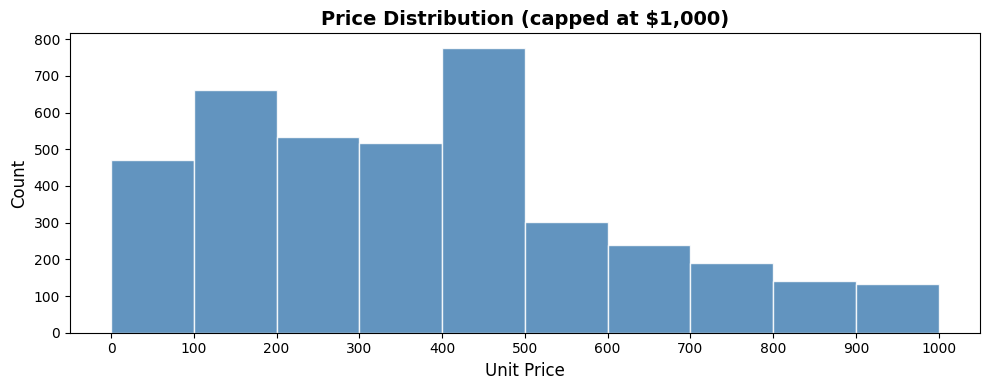

In [35]:
# Price distribution histogram
fig, ax = plt.subplots(figsize=(10, 4))
counts, bin_edges, _ = ax.hist(
    df['price'].dropna(), bins=10, range=(0, 1000),
    color='steelblue', edgecolor='white', alpha=0.85
)
ax.set_xticks(bin_edges.round(0))
ax.set_xlabel('Unit Price', fontsize=12)
ax.set_ylabel('Count', fontsize=12)
ax.set_title('Price Distribution (capped at $1,000)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

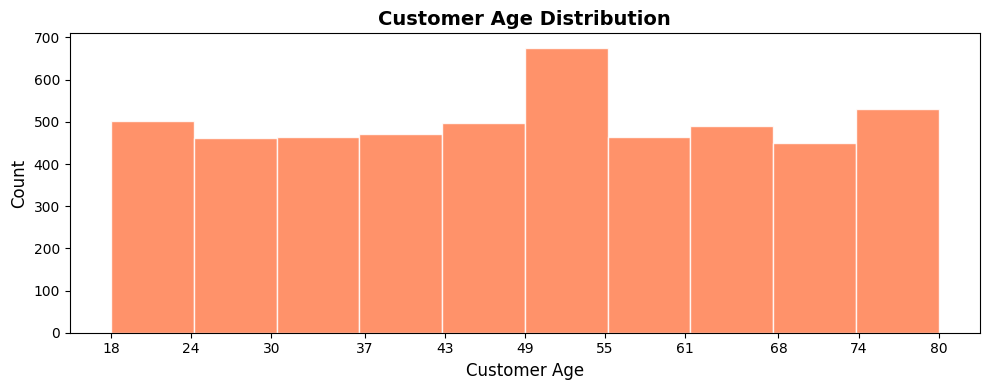

In [36]:
# Customer age distribution histogram
fig, ax = plt.subplots(figsize=(10, 4))
counts, bin_edges, _ = ax.hist(
    df['customer_age'].dropna(), bins=10,
    color='coral', edgecolor='white', alpha=0.85
)
ax.set_xticks(bin_edges.round(0))
ax.set_xlabel('Customer Age', fontsize=12)
ax.set_ylabel('Count', fontsize=12)
ax.set_title('Customer Age Distribution', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

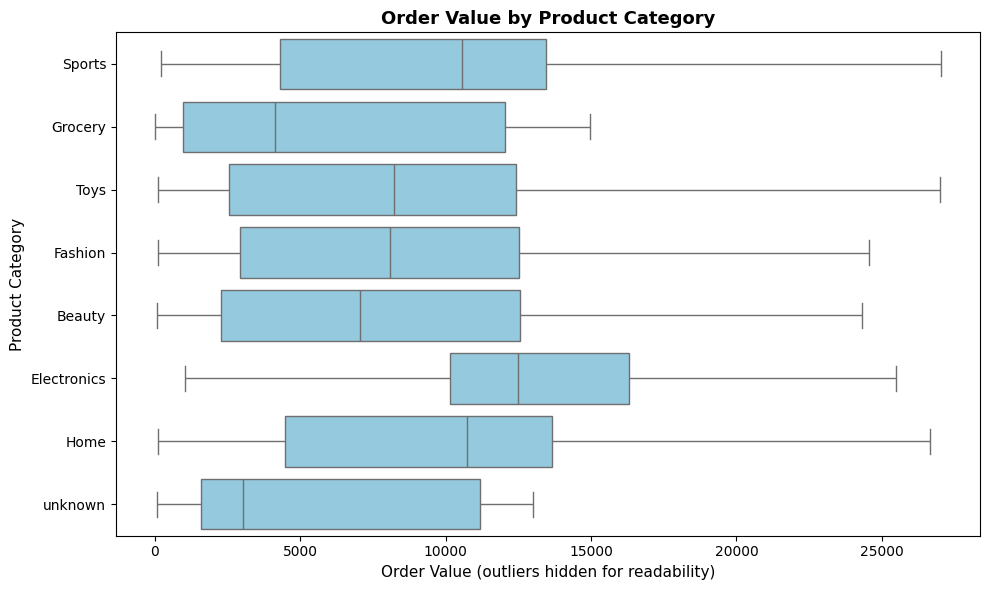

In [41]:
# Boxplot: order_value across all product categories
fig, ax = plt.subplots(figsize=(10, 6))
sns.boxplot(data=df, y='product_category', x='order_value', color='skyblue', ax=ax, showfliers=False)
ax.set_xlabel('Order Value (outliers hidden for readability)', fontsize=11)
ax.set_ylabel('Product Category', fontsize=11)
ax.set_title('Order Value by Product Category', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

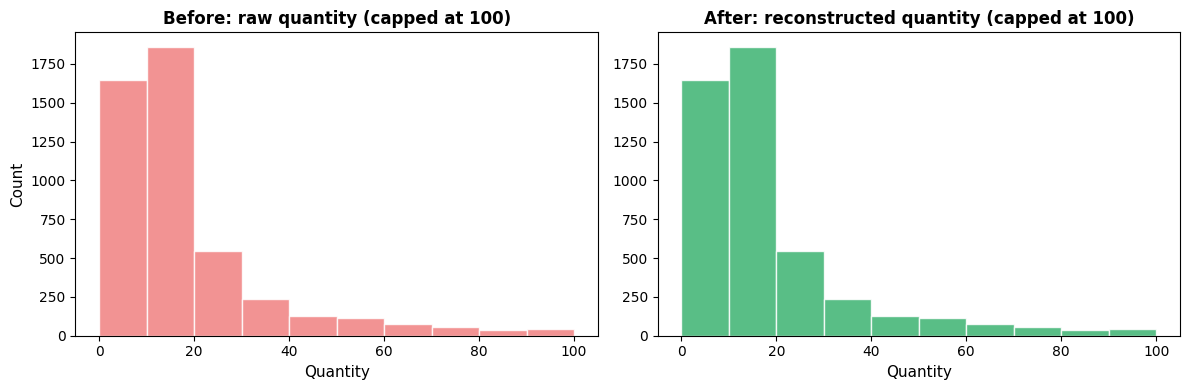

In [45]:
# Quantity distribution: before vs. after reconstructing the 0-sentinel
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].hist(df_raw['quantity'], bins=10, range=(0, 100), color='lightcoral', edgecolor='white', alpha=0.85)
axes[0].set_xlabel('Quantity', fontsize=11)
axes[0].set_ylabel('Count', fontsize=11)
axes[0].set_title('Before: raw quantity (capped at 100)', fontsize=12, fontweight='bold')

axes[1].hist(df['quantity'], bins=10, range=(0, 100), color='mediumseagreen', edgecolor='white', alpha=0.85)
axes[1].set_xlabel('Quantity', fontsize=11)
axes[1].set_title('After: reconstructed quantity (capped at 100)', fontsize=12, fontweight='bold')

plt.tight_layout()
plt.show()

---
## 6. Outlier Detection

I applied both the IQR method and Z-score to `order_value` and `price`, then compared how many records each method flagged. The IQR method tends to be more aggressive with right-skewed data, while Z-score is stricter and better suited to near-normal distributions. Running both gives a clearer picture of which extreme values are genuine anomalies versus expected high-value transactions.

In [21]:
# 6.1 IQR method on order_value
Q1  = df['order_value'].quantile(0.25)
Q3  = df['order_value'].quantile(0.75)
IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

outliers_iqr = df[(df['order_value'] < lower) | (df['order_value'] > upper)]

print(f'Q1: {Q1:,.0f}  |  Q3: {Q3:,.0f}  |  IQR: {IQR:,.0f}')
print(f'Lower fence: {lower:,.0f}  |  Upper fence: {upper:,.0f}')
print(f'\nOutliers detected (IQR): {len(outliers_iqr):,} records')

Q1: 3,096  |  Q3: 13,159  |  IQR: 10,063
Lower fence: -11,998  |  Upper fence: 28,254

Outliers detected (IQR): 165 records


In [22]:
# 6.2 Z-score method on order_value
mean_ov = df['order_value'].mean()
std_ov  = df['order_value'].std()

df['z_order_value'] = (df['order_value'] - mean_ov) / std_ov

outliers_z = df[df['z_order_value'].abs() > 3]
print(f'Outliers detected (|Z| > 3): {len(outliers_z):,} records')

Outliers detected (|Z| > 3): 63 records


In [23]:
# 6.3 Method comparison on price
Q1_p  = df['price'].quantile(0.25)
Q3_p  = df['price'].quantile(0.75)
IQR_p = Q3_p - Q1_p
lower_p = Q1_p - 1.5 * IQR_p
upper_p = Q3_p + 1.5 * IQR_p

mean_p = df['price'].mean()
std_p  = df['price'].std()
df['z_price'] = (df['price'] - mean_p) / std_p

iqr_count = len(df[(df['price'] < lower_p) | (df['price'] > upper_p)])
z_count   = len(df[df['z_price'].abs() > 3])

print(f'Price outliers — IQR method:     {iqr_count:,}')
print(f'Price outliers — Z-score method: {z_count:,}')
print('\nIQR flagged more records, consistent with a right-skewed price distribution.')

Price outliers — IQR method:     447
Price outliers — Z-score method: 78

IQR flagged more records, consistent with a right-skewed price distribution.


---
## 7. Feature Engineering — Customer Segmentation

To add analytical value beyond raw columns, I created three new segmentation features. The first uses `np.where()` for a simple binary split on purchase volume. The second combines volume and age into four customer profiles using `apply()` with a custom function. The third segments by payment method and volume to identify behavioral patterns that could be relevant for targeted strategies.

In [24]:
# 7.1 Simple binary segmentation with np.where()
df['volume_segment'] = np.where(
    df['quantity'] > 22, 'High Volume', 'Low Volume'
)

print('Volume segment distribution:')
print(df['volume_segment'].value_counts())

Volume segment distribution:
volume_segment
Low Volume     3766
High Volume    1242
Name: count, dtype: int64


In [25]:
# 7.2 Multi-condition segmentation with apply()

def classify_customer(row):
    """Classify customers by purchase volume and age group."""
    age = row['customer_age']
    qty = row['quantity']

    if pd.isna(age) or pd.isna(qty):
        return 'Data Error'

    if qty > 22:
        return 'Sr. High Volume' if age > 55 else 'Jr. High Volume'
    else:
        return 'Sr. Low Volume' if age > 55 else 'Jr. Low Volume'


df['customer_segment'] = df.apply(classify_customer, axis=1)

print('Customer segment breakdown:')
print(df['customer_segment'].value_counts())

Customer segment breakdown:
customer_segment
Jr. Low Volume     2855
Sr. High Volume    1199
Sr. Low Volume      736
Data Error          175
Jr. High Volume      43
Name: count, dtype: int64


In [26]:
# 7.3 Payment behaviour segmentation

def classify_payment(row):
    """Segment transactions by payment type and purchase volume."""
    method = row['payment_method']
    qty    = row['quantity']

    if pd.isna(method) or pd.isna(qty):
        return 'Data Error'

    is_card = method in ('credit_card', 'debit_card')
    prefix  = 'card' if is_card else 'no_card'
    volume  = 'high' if qty > 22 else 'low'
    return f'{prefix}_{volume}_volume'


df['payment_segment'] = df.apply(classify_payment, axis=1)

print('Payment segment breakdown:')
print(df['payment_segment'].value_counts())

Payment segment breakdown:
payment_segment
card_low_volume        2725
no_card_low_volume     1041
card_high_volume        909
no_card_high_volume     333
Name: count, dtype: int64


---
## 8. Summary & Key Findings

| Topic | Finding |
|---|---|
| Missing values | `city` and `state` had the highest null rates; `order_date` contained future-dated records requiring filtering |
| Missingness pattern | Null rate for `city` varied across payment method groups, indicating MAR — handled with conditional logic rather than global imputation |
| Distribution shape | `price` is right-skewed (mean 756 vs. median 457); `order_value` is approximately symmetric (mean 10,072 vs. median 10,340), consistent with the Section 4.2 diagnostic |
| Outlier detection | IQR flagged more records than Z-score on `price`, consistent with its right-skewed shape; on the more symmetric `order_value`, the two methods showed a smaller gap |
| Customer segments | Four segments created from age and purchase volume; payment-based segmentation adds a behavioral dimension for downstream targeting |

---

All transformations are encapsulated in reusable functions. The pipeline can be applied to any dataset sharing this schema by updating `FILE_PATH`.